# Research Profile Builder

This notebook builds comprehensive research profiles for each person in the Klab Profile List using:
- **OpenAlex API**: Publication data, citations, h-index, research topics
- **Google Scholar**: Additional publication metrics and citations
- **Web scraping**: Personal website information
- **Existing biographical data**: From the Excel file

## Setup and Dependencies

In [1]:
# Install required packages if needed
# \!pip install pandas openpyxl requests scholarly beautifulsoup4 tqdm

In [2]:
import pandas as pd
import requests
import json
import time
from typing import Dict, List, Optional, Any
from dataclasses import dataclass, asdict, field
from datetime import datetime
import re
from urllib.parse import quote
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

## Load Klab Profile List

In [3]:
# Load the Excel file
df = pd.read_excel('Klab Profile List.xlsx')
print(f"Loaded {len(df)} profiles")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTeam Member Types: {df['Team Member Type'].value_counts().to_dict()}")
df.head()

Loaded 68 profiles

Columns: ['First Name', 'Last Name', 'Email Address', 'Institution', 'Bio ', 'Personal Website', 'Publication Links', 'Team Member Type', 'Photo Link']

Team Member Types: {'Affiliate Faculty': 27, 'PhD Student': 18, 'Postdoctoral Scholar': 9, 'Masters Student': 5, 'Affiliate Researcher': 4, 'Alumni': 3, 'Undergraduate Student': 1, 'Assistant Director': 1}


,First Name,Last Name,Email Address,Institution,Bio,Personal Website,Publication Links,Team Member Type,Photo Link
0,Yong-Yeol,Ahn,yyahn@iu.edu,Indiana University,Yong-Yeol Ahn earned his Ph.D. in physics from...,NaN,NaN,Affiliate Faculty,https://drive.google.com/file/d/1YeRtgY__DuMlU...
1,Ufuk,Akcigit,uakcigit@uchicago.edu,University of Chicago,Ufuk Akcigit is the Arnold C. Harberger Profes...,https://www.ufukakcigit.com/,NaN,Affiliate Faculty,https://drive.google.com/file/d/1WJALGEW-1383u...
2,Jacy,Anthis,anthis@uchicago.edu,University of Chicago,Jacy Anthis is a joint PhD candidate with the ...,https://jacyanthis.com,NaN,PhD Student,https://drive.google.com/file/d/142xwXeMPkgid4...
3,Honglin,Bao,honglinbao@uchicago.edu,University of Chicago,Honglin Bao (he/him) is a doctoral student in ...,www.hbao.info,NaN,PhD Student,https://drive.google.com/file/d/1EtSCS_bLzDRxi...
4,Carolina,Biliotti,carolina.biliotti@imtlucca.it,"IMT School for Advanced Studies Lucca, Italy",Carolina Biliotti is a fourth-year PhD student...,https://www.researchgate.net/profile/Carolina-...,NaN,PhD Student,https://drive.google.com/file/d/1ScN4Cj7iUKXkP...


## Data Classes for Research Profiles

In [4]:
@dataclass
class Publication:
    """Represents a single publication"""
    title: str
    year: Optional[int]
    doi: Optional[str]
    citation_count: int
    venue: Optional[str]
    authors: List[str]
    openalex_id: Optional[str] = None
    abstract: Optional[str] = None
    topics: List[str] = field(default_factory=list)

@dataclass
class OpenAlexMetrics:
    """Metrics from OpenAlex"""
    author_id: Optional[str]
    display_name: str
    works_count: int
    cited_by_count: int
    h_index: Optional[int]
    i10_index: Optional[int]
    institutions: List[str]
    topics: List[Dict[str, Any]]
    recent_publications: List[Publication]
    orcid: Optional[str] = None
    match_method: Optional[str] = None  # 'DOI', 'Title', or 'Name'

@dataclass  
class GoogleScholarMetrics:
    """Metrics from Google Scholar"""
    scholar_id: Optional[str]
    citations: int
    h_index: int
    i10_index: int
    interests: List[str]
    top_publications: List[Dict[str, Any]]

@dataclass
class ResearchProfile:
    """Complete research profile for a person"""
    # Basic info from Excel
    first_name: str
    last_name: str
    email: str
    institution: str
    bio: Optional[str]
    personal_website: Optional[str]
    team_member_type: str
    photo_link: Optional[str]
    
    # Research metrics
    openalex_metrics: Optional[OpenAlexMetrics] = None
    google_scholar_metrics: Optional[GoogleScholarMetrics] = None
    
    # Additional info
    website_info: Optional[Dict[str, Any]] = None
    
    # Metadata
    profile_generated_at: str = field(default_factory=lambda: datetime.now().isoformat())
    
    @property
    def full_name(self) -> str:
        return f"{self.first_name} {self.last_name}"

## OpenAlex API Integration

OpenAlex is a free, open catalog of scholarly works. We use it to fetch:
- Publication counts and citations
- h-index and i10-index
- Research topics and concepts
- Co-authors and institutional affiliations

## Publication Link Parser

Extract identifiers from the Publication Links column to improve matching:
- Google Scholar IDs
- DOIs from paper links
- ORCID IDs

In [5]:
class PublicationLinkParser:
    """Parse publication links to extract useful identifiers"""
    
    def __init__(self):
        # Regex patterns for various identifiers
        self.doi_pattern = re.compile(r'10\.\d{4,}/[^\s,\]\"\'<>]+')
        self.scholar_id_pattern = re.compile(r'scholar\.google\.com/citations\?user=([A-Za-z0-9_-]+)')
        self.orcid_pattern = re.compile(r'orcid\.org/(\d{4}-\d{4}-\d{4}-\d{3}[0-9X])')
        self.arxiv_pattern = re.compile(r'arxiv\.org/abs/(\d+\.\d+)')
    
    def extract_paper_titles(self, text: str) -> List[str]:
        """Extract potential paper titles from text"""
        if pd.isna(text) or not text:
            return []
        
        text = str(text)
        titles = []
        
        # Look for quoted titles
        quoted = re.findall(r'"([^"]{20,150})"', text)
        titles.extend(quoted)
        
        # Look for titles in common citation formats
        # Pattern: "Title" or Title, Journal/Conference
        # Also match titles that appear before year in parentheses
        title_patterns = [
            r'["\"]([^"\"]{20,150})["\"]',  # Quoted titles
            r'(?:^|\n)([A-Z][^.!?\n]{20,120})[.,]?\s*(?:Nature|Science|PNAS|ICSE|ACL|NeurIPS|ICML|KDD|WWW|Proceedings)',  # Before journal
            r'(?:^|\.\s+)([A-Z][A-Za-z\s,:\-\']+(?:learning|networks?|science|analysis|models?|systems?|discovery|inference|dynamics|behavior|innovation)[^.]{0,50})[.,]',  # Topic keywords
        ]
        
        for pattern in title_patterns:
            matches = re.findall(pattern, text, re.IGNORECASE | re.MULTILINE)
            for match in matches:
                # Clean up the title
                title = match.strip().strip('.,;:')
                if len(title) > 20 and len(title) < 200:
                    # Remove author names at the start (e.g., "Smith, J. Title here")
                    if not re.match(r'^[A-Z][a-z]+,\s+[A-Z]\.', title):
                        titles.append(title)
        
        # Also try splitting by newlines and looking for title-like strings
        lines = text.split('\n')
        for line in lines:
            line = line.strip()
            # Skip if it looks like an author list or URL
            if re.match(r'^https?://', line) or re.match(r'^[A-Z][a-z]+,.*et\.?\s*al', line):
                continue
            # Look for lines that could be titles (capitalized, reasonable length)
            if 25 < len(line) < 150 and line[0].isupper():
                # Check if it contains title-like words
                title_words = ['learning', 'network', 'model', 'analysis', 'science', 'social', 
                              'data', 'algorithm', 'system', 'discovery', 'prediction', 'human',
                              'language', 'knowledge', 'innovation', 'team', 'research']
                if any(word in line.lower() for word in title_words):
                    titles.append(line.split('.')[0].strip())  # Take text before first period
        
        # Deduplicate while preserving order
        seen = set()
        unique_titles = []
        for t in titles:
            t_lower = t.lower()
            if t_lower not in seen and len(t) > 20:
                seen.add(t_lower)
                unique_titles.append(t)
        
        return unique_titles[:10]  # Return up to 10 titles
    
    def parse(self, links_text: str) -> Dict[str, Any]:
        """Parse publication links text and extract identifiers"""
        if pd.isna(links_text) or not links_text:
            return {'dois': [], 'scholar_id': None, 'orcid': None, 'arxiv_ids': [], 'paper_titles': [], 'raw_text': None}
        
        links_text = str(links_text)
        
        # Extract DOIs
        dois = list(set(self.doi_pattern.findall(links_text)))
        dois = [doi.rstrip('.,;)') for doi in dois]
        
        # Extract Google Scholar ID
        scholar_match = self.scholar_id_pattern.search(links_text)
        scholar_id = scholar_match.group(1) if scholar_match else None
        
        # Extract ORCID
        orcid_match = self.orcid_pattern.search(links_text)
        orcid = orcid_match.group(1) if orcid_match else None
        
        # Extract arXiv IDs
        arxiv_ids = list(set(self.arxiv_pattern.findall(links_text)))
        
        # Extract paper titles
        paper_titles = self.extract_paper_titles(links_text)
        
        return {
            'dois': dois,
            'scholar_id': scholar_id,
            'orcid': orcid,
            'arxiv_ids': arxiv_ids,
            'paper_titles': paper_titles,
            'raw_text': links_text[:500] if len(links_text) > 500 else links_text
        }

# Test the parser with title extraction
parser = PublicationLinkParser()

print("Testing paper title extraction:")
print("="*60)

# Test with a few examples
test_cases = [
    ('Doug Guilbeault', df[df['Last Name'] == 'Guilbeault']['Publication Links'].iloc[0] if len(df[df['Last Name'] == 'Guilbeault']) > 0 else ''),
    ('Donghyun Kang', df[df['Last Name'] == 'Kang']['Publication Links'].iloc[0] if len(df[df['Last Name'] == 'Kang']) > 0 else ''),
    ('Bernard Koch', df[df['Last Name'] == 'Koch']['Publication Links'].iloc[0] if len(df[df['Last Name'] == 'Koch']) > 0 else ''),
]

for name, pub_links in test_cases:
    if pub_links and not pd.isna(pub_links):
        parsed = parser.parse(pub_links)
        print(f"\n{name}:")
        print(f"  DOIs: {len(parsed['dois'])}")
        print(f"  Paper titles found: {len(parsed['paper_titles'])}")
        for title in parsed['paper_titles'][:3]:
            print(f"    - {title[:70]}{'...' if len(title) > 70 else ''}")

Testing paper title extraction:

Doug Guilbeault:
  DOIs: 0
  Paper titles found: 2
    - Divergences in Color Perception between Deep Neural Networks and Human...
    - Signal in Noise: Exploring Meaning Encoded in Random Character Sequenc...

Donghyun Kang:
  DOIs: 1
  Paper titles found: 2
    - Against method: Exploding the boundary between qualitative and quantit...
    - Against method: Exploding the boundary between qualitative and quantit...

Bernard Koch:
  DOIs: 0
  Paper titles found: 4
    - Deep Learning for Causal Inference
    - Reduced, reused and recycled: The life of a machine learning dataset
    - HINTS: time series prediction via dynamic heterogeneous information ne...


In [6]:
class OpenAlexClient:
    """Client for querying the OpenAlex API"""
    
    BASE_URL = "https://api.openalex.org"
    
    def __init__(self, email: str = "klab@uchicago.edu"):
        """Initialize with a polite email for API requests"""
        self.email = email
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': f'ResearchProfileBuilder/1.0 (mailto:{email})'
        })
    
    def _make_request(self, endpoint: str, params: Dict = None) -> Optional[Dict]:
        """Make a request to the OpenAlex API"""
        url = f"{self.BASE_URL}/{endpoint}"
        if params is None:
            params = {}
        params['mailto'] = self.email
        
        try:
            response = self.session.get(url, params=params, timeout=30)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            if '404' not in str(e) and '400' not in str(e):
                print(f"Error fetching {endpoint}: {e}")
            return None
    
    def get_work_by_doi(self, doi: str) -> Optional[Dict]:
        """Get a work by its DOI"""
        doi = doi.strip()
        if doi.startswith('https://doi.org/'):
            doi = doi[16:]
        elif doi.startswith('http://doi.org/'):
            doi = doi[15:]
        return self._make_request(f'works/https://doi.org/{doi}')
    
    def search_works_by_title(self, title: str, limit: int = 5) -> List[Dict]:
        """Search for works by title"""
        # Clean up the title for search
        title_clean = re.sub(r'[^\w\s]', ' ', title)
        title_clean = ' '.join(title_clean.split()[:12])  # First 12 words
        
        params = {
            'search': title_clean,
            'per_page': limit
        }
        result = self._make_request('works', params)
        return result.get('results', []) if result else []
    
    def find_author_by_title(self, titles: List[str], target_name: str) -> Optional[Dict]:
        """Find an author by searching for their paper titles"""
        target_lower = target_name.lower()
        target_parts = target_lower.split()
        
        for title in titles[:5]:  # Check up to 5 titles
            works = self.search_works_by_title(title)
            
            for work in works:
                work_title = work.get('title', '').lower()
                # Check if this is likely the right paper (fuzzy title match)
                title_words = set(title.lower().split())
                work_words = set(work_title.split())
                overlap = len(title_words & work_words) / max(len(title_words), 1)
                
                if overlap < 0.4:  # Less than 40% word overlap, probably wrong paper
                    continue
                
                # Look for the target author
                for authorship in work.get('authorships', []):
                    author = authorship.get('author', {})
                    author_name = author.get('display_name', '').lower()
                    author_parts = author_name.split()
                    
                    # Check for name match
                    if len(target_parts) >= 2 and len(author_parts) >= 2:
                        target_last = target_parts[-1]
                        author_last = author_parts[-1]
                        
                        if target_last == author_last:
                            target_first = target_parts[0]
                            author_first = author_parts[0]
                            
                            if target_first == author_first or target_first[0] == author_first[0]:
                                # Match found! Get full author data
                                author_id = author.get('id')
                                if author_id:
                                    full_author = self.get_author_by_id(author_id.split('/')[-1])
                                    if full_author:
                                        return full_author
            time.sleep(0.3)
        
        return None
    
    def find_author_by_doi(self, dois: List[str], target_name: str) -> Optional[Dict]:
        """Find an author by looking up their DOIs and matching by name"""
        target_lower = target_name.lower()
        target_parts = target_lower.split()
        
        for doi in dois[:5]:
            work = self.get_work_by_doi(doi)
            if work:
                for authorship in work.get('authorships', []):
                    author = authorship.get('author', {})
                    author_name = author.get('display_name', '').lower()
                    author_parts = author_name.split()
                    
                    if len(target_parts) >= 2 and len(author_parts) >= 2:
                        target_last = target_parts[-1]
                        author_last = author_parts[-1]
                        
                        if target_last == author_last:
                            target_first = target_parts[0]
                            author_first = author_parts[0]
                            
                            if target_first == author_first or target_first[0] == author_first[0]:
                                author_id = author.get('id')
                                if author_id:
                                    full_author = self.get_author_by_id(author_id.split('/')[-1])
                                    if full_author:
                                        return full_author
            time.sleep(0.3)
        
        return None
    
    def search_author(self, name: str, institution: str = None) -> Optional[Dict]:
        """Search for an author by name and optionally institution"""
        params = {
            'search': name,
            'per_page': 10
        }
        
        result = self._make_request('authors', params)
        
        if result and result.get('results'):
            name_lower = name.lower()
            for author in result['results']:
                display_name = author.get('display_name', '').lower()
                if name_lower in display_name or display_name in name_lower:
                    return author
            return result['results'][0]
        return None
    
    def get_author_by_id(self, author_id: str) -> Optional[Dict]:
        """Get detailed author information by OpenAlex ID"""
        if author_id.startswith('https://'):
            author_id = author_id.split('/')[-1]
        return self._make_request(f'authors/{author_id}')
    
    def get_author_works(self, author_id: str, limit: int = 25) -> List[Dict]:
        """Get an author's publications"""
        if author_id.startswith('https://'):
            author_id = author_id.split('/')[-1]
        params = {
            'filter': f'author.id:{author_id}',
            'sort': 'cited_by_count:desc',
            'per_page': limit
        }
        result = self._make_request('works', params)
        return result.get('results', []) if result else []
    
    def build_metrics(self, author_data: Dict, works: List[Dict]) -> OpenAlexMetrics:
        """Build OpenAlexMetrics from API response data"""
        institutions = []
        for aff in author_data.get('affiliations', []):
            if aff.get('institution'):
                institutions.append(aff['institution'].get('display_name', ''))
        
        topics = []
        for topic in author_data.get('topics', [])[:10]:
            topics.append({
                'name': topic.get('display_name', ''),
                'count': topic.get('count', 0)
            })
        
        publications = []
        for work in works[:10]:
            pub = Publication(
                title=work.get('title', 'Untitled'),
                year=work.get('publication_year'),
                doi=work.get('doi'),
                citation_count=work.get('cited_by_count', 0),
                venue=work.get('primary_location', {}).get('source', {}).get('display_name') if work.get('primary_location') else None,
                authors=[a.get('author', {}).get('display_name', '') for a in work.get('authorships', [])[:5]],
                openalex_id=work.get('id'),
                abstract=work.get('abstract'),
                topics=[t.get('display_name', '') for t in work.get('topics', [])[:5]]
            )
            publications.append(pub)
        
        summary = author_data.get('summary_stats', {})
        
        return OpenAlexMetrics(
            author_id=author_data.get('id'),
            display_name=author_data.get('display_name', ''),
            works_count=author_data.get('works_count', 0),
            cited_by_count=author_data.get('cited_by_count', 0),
            h_index=summary.get('h_index'),
            i10_index=summary.get('i10_index'),
            institutions=institutions,
            topics=topics,
            recent_publications=publications,
            orcid=author_data.get('orcid')
        )

In [7]:
# Test DOI-based lookup
openalex = OpenAlexClient()

# Test with a known DOI from Doug Guilbeault
test_doi = "10.1038/s41586-024-07068-x"  # Nature paper on Online Images Amplify Gender Bias
print(f"Testing DOI-based lookup with: {test_doi}")

work = openalex.get_work_by_doi(test_doi)
if work:
    print(f"Found work: {work.get('title', 'Unknown')[:60]}...")
    print(f"Authors: {[a['author']['display_name'] for a in work.get('authorships', [])[:5]]}")
    
    # Try to find Doug Guilbeault
    author = openalex.find_author_by_doi([test_doi], "Doug Guilbeault")
    if author:
        print(f"\n✓ Found author via DOI: {author.get('display_name')}")
        print(f"  Works: {author.get('works_count')}, Citations: {author.get('cited_by_count')}")
else:
    print("Work not found")

Testing DOI-based lookup with: 10.1038/s41586-024-07068-x


Found work: Online images amplify gender bias...
Authors: ['Douglas Guilbeault', 'Solène Delecourt', 'Tasker Hull', 'Bhargav Srinivasa Desikan', 'Mark Chu']



✓ Found author via DOI: Douglas Guilbeault
  Works: 57, Citations: 1204


## Google Scholar Integration

Using the `scholarly` library to fetch Google Scholar profiles. Note: Google Scholar may rate-limit requests.

In [8]:
# Try to import scholarly, with fallback
try:
    from scholarly import scholarly
    SCHOLARLY_AVAILABLE = True
except ImportError:
    print("scholarly not installed. Run: pip install scholarly")
    SCHOLARLY_AVAILABLE = False

class GoogleScholarClient:
    """Client for querying Google Scholar via scholarly library"""
    
    def __init__(self):
        self.available = SCHOLARLY_AVAILABLE
        if not self.available:
            print("Warning: Google Scholar integration unavailable")
    
    def search_author(self, name: str, institution: str = None) -> Optional[GoogleScholarMetrics]:
        """Search for an author on Google Scholar"""
        if not self.available:
            return None
        
        try:
            # Search for author
            search_query = scholarly.search_author(name)
            
            # Get first result that matches institution if possible
            for author in search_query:
                if institution:
                    affiliation = author.get('affiliation', '').lower()
                    if any(word in affiliation for word in institution.lower().split()):
                        author_data = scholarly.fill(author)
                        return self._build_metrics(author_data)
                else:
                    author_data = scholarly.fill(author)
                    return self._build_metrics(author_data)
            
            return None
        except Exception as e:
            print(f"Google Scholar error for {name}: {e}")
            return None
    
    def _build_metrics(self, author_data: Dict) -> GoogleScholarMetrics:
        """Build GoogleScholarMetrics from scholarly data"""
        # Get top publications
        top_pubs = []
        for pub in author_data.get('publications', [])[:10]:
            top_pubs.append({
                'title': pub.get('bib', {}).get('title', ''),
                'citations': pub.get('num_citations', 0),
                'year': pub.get('bib', {}).get('pub_year', '')
            })
        
        return GoogleScholarMetrics(
            scholar_id=author_data.get('scholar_id'),
            citations=author_data.get('citedby', 0),
            h_index=author_data.get('hindex', 0),
            i10_index=author_data.get('i10index', 0),
            interests=author_data.get('interests', []),
            top_publications=top_pubs
        )

## Website Information Extraction

Extract additional information from personal websites when available.

In [9]:
from bs4 import BeautifulSoup

class WebsiteExtractor:
    """Extract information from personal/institutional websites"""
    
    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
        })
        self.doi_pattern = re.compile(r'10\.\d{4,}/[^\s,\]\"\'<>\)]+')
        self.scholar_pattern = re.compile(r'scholar\.google\.com/citations\?user=([A-Za-z0-9_-]+)')
        self.orcid_pattern = re.compile(r'orcid\.org/(\d{4}-\d{4}-\d{4}-\d{3}[0-9X])')
    
    def extract_info(self, url: str, verbose: bool = False) -> Optional[Dict[str, Any]]:
        """Extract information from a website including publications"""
        if not url or pd.isna(url):
            return None
        
        # Ensure URL has protocol
        if not url.startswith('http'):
            url = 'https://' + url
        
        try:
            response = self.session.get(url, timeout=15, allow_redirects=True)
            response.raise_for_status()
            
            soup = BeautifulSoup(response.text, 'html.parser')
            
            info = {
                'url': url,
                'title': soup.title.string.strip() if soup.title and soup.title.string else None,
                'meta_description': None,
                'dois': [],
                'paper_titles': [],
                'scholar_id': None,
                'orcid': None,
                'research_interests': [],
                'bio_text': None,
                'publication_links': []
            }
            
            # Get full page text for analysis
            page_text = response.text
            
            # Extract DOIs from page
            dois = list(set(self.doi_pattern.findall(page_text)))
            info['dois'] = [doi.rstrip('.,;)') for doi in dois][:20]  # Limit to 20
            
            # Extract Google Scholar ID
            scholar_match = self.scholar_pattern.search(page_text)
            if scholar_match:
                info['scholar_id'] = scholar_match.group(1)
            
            # Extract ORCID
            orcid_match = self.orcid_pattern.search(page_text)
            if orcid_match:
                info['orcid'] = orcid_match.group(1)
            
            # Get meta description
            meta_desc = soup.find('meta', attrs={'name': 'description'})
            if meta_desc:
                info['meta_description'] = meta_desc.get('content')
            
            # Extract publication titles from common patterns
            paper_titles = self._extract_paper_titles(soup, page_text)
            info['paper_titles'] = paper_titles[:15]  # Limit to 15
            
            # Extract research interests/keywords
            info['research_interests'] = self._extract_research_interests(soup, page_text)
            
            # Extract bio text
            info['bio_text'] = self._extract_bio(soup)
            
            # Find links to publication pages
            pub_links = self._find_publication_links(soup, url)
            info['publication_links'] = pub_links
            
            if verbose:
                print(f"    Website: {len(info['dois'])} DOIs, {len(info['paper_titles'])} titles found")
                if info['scholar_id']:
                    print(f"    Google Scholar ID: {info['scholar_id']}")
                if info['orcid']:
                    print(f"    ORCID: {info['orcid']}")
            
            return info
            
        except Exception as e:
            if verbose:
                print(f"    Error extracting from {url}: {e}")
            return None
    
    def _extract_paper_titles(self, soup: BeautifulSoup, page_text: str) -> List[str]:
        """Extract paper titles from the page"""
        titles = []
        
        # Look for common publication list patterns
        # 1. List items that look like paper titles
        for li in soup.find_all('li'):
            text = li.get_text(strip=True)
            # Paper titles are usually 30-200 chars and contain certain keywords
            if 30 < len(text) < 300:
                # Check if it looks like a citation
                if re.search(r'\(\d{4}\)|,\s*\d{4}|Nature|Science|PNAS|ACL|NeurIPS|ICML|Proceedings', text):
                    # Extract the title part (usually before the journal/year)
                    # Try to get text before first period or parenthesis with year
                    title_match = re.match(r'^["\"]?([^."\(]{25,150})', text)
                    if title_match:
                        title = title_match.group(1).strip().strip('"\'')
                        if not re.match(r'^(https?://|[A-Z][a-z]+,\s+[A-Z]\.)', title):
                            titles.append(title)
        
        # 2. Look for publication sections
        pub_sections = soup.find_all(['div', 'section'], class_=re.compile(r'pub|paper|article|research', re.I))
        for section in pub_sections:
            for elem in section.find_all(['h3', 'h4', 'p', 'a']):
                text = elem.get_text(strip=True)
                if 30 < len(text) < 200 and not text.startswith('http'):
                    titles.append(text)
        
        # 3. Look for links that might be paper titles
        for a in soup.find_all('a', href=True):
            href = a.get('href', '')
            text = a.get_text(strip=True)
            # Links to DOIs or arxiv that have descriptive text
            if ('doi.org' in href or 'arxiv.org' in href) and 20 < len(text) < 200:
                titles.append(text)
        
        # Deduplicate
        seen = set()
        unique = []
        for t in titles:
            t_lower = t.lower()[:50]  # Compare first 50 chars
            if t_lower not in seen:
                seen.add(t_lower)
                unique.append(t)
        
        return unique
    
    def _extract_research_interests(self, soup: BeautifulSoup, page_text: str) -> List[str]:
        """Extract research interests/keywords"""
        interests = []
        
        # Look for meta keywords
        meta_kw = soup.find('meta', attrs={'name': 'keywords'})
        if meta_kw and meta_kw.get('content'):
            interests.extend([k.strip() for k in meta_kw['content'].split(',')])
        
        # Look for sections about research
        research_keywords = ['research interest', 'research area', 'expertise', 'focus', 'specializ']
        for section in soup.find_all(['div', 'section', 'p']):
            text = section.get_text(strip=True).lower()
            if any(kw in text for kw in research_keywords) and len(text) < 500:
                # Extract comma-separated or bullet items
                items = re.findall(r'(?:^|[,;•·-])\s*([A-Za-z][A-Za-z\s]{5,40})(?=[,;•·-]|$)', section.get_text())
                interests.extend([i.strip() for i in items if len(i.strip()) > 5])
        
        return list(set(interests))[:10]
    
    def _extract_bio(self, soup: BeautifulSoup) -> Optional[str]:
        """Extract biographical text"""
        # Look for about/bio sections
        bio_patterns = ['about', 'bio', 'profile', 'introduction']
        
        for pattern in bio_patterns:
            sections = soup.find_all(['div', 'section', 'p'], 
                                     class_=re.compile(pattern, re.I))
            for section in sections:
                text = section.get_text(strip=True)
                if 100 < len(text) < 2000:
                    return text[:1000]
        
        # Try to find first substantial paragraph
        for p in soup.find_all('p'):
            text = p.get_text(strip=True)
            if 100 < len(text) < 1000 and not text.startswith('http'):
                return text
        
        return None
    
    def _find_publication_links(self, soup: BeautifulSoup, base_url: str) -> List[Dict]:
        """Find links to publication pages"""
        pub_links = []
        pub_keywords = ['publication', 'paper', 'research', 'article', 'cv', 'resume', 'scholar']
        
        for link in soup.find_all('a', href=True):
            href = link.get('href', '').lower()
            text = link.get_text(strip=True).lower()
            
            if any(kw in href or kw in text for kw in pub_keywords):
                full_url = href
                if not href.startswith('http'):
                    from urllib.parse import urljoin
                    full_url = urljoin(base_url, href)
                
                pub_links.append({
                    'text': link.get_text(strip=True),
                    'url': full_url
                })
        
        return pub_links[:10]
    
    def fetch_publication_page(self, url: str) -> Optional[Dict]:
        """Fetch a publication page and extract DOIs/titles"""
        try:
            response = self.session.get(url, timeout=15)
            response.raise_for_status()
            
            soup = BeautifulSoup(response.text, 'html.parser')
            page_text = response.text
            
            dois = list(set(self.doi_pattern.findall(page_text)))
            titles = self._extract_paper_titles(soup, page_text)
            
            return {
                'url': url,
                'dois': [doi.rstrip('.,;)') for doi in dois][:30],
                'titles': titles[:20]
            }
        except:
            return None

## Profile Builder

Main class that combines all data sources to build comprehensive research profiles.

In [10]:
class ProfileBuilder:
    """Build comprehensive research profiles from multiple sources"""
    
    def __init__(self, use_google_scholar: bool = False):
        self.openalex = OpenAlexClient()
        self.google_scholar = GoogleScholarClient() if use_google_scholar else None
        self.website_extractor = WebsiteExtractor()
        self.link_parser = PublicationLinkParser()
        
    def build_profile(self, row: pd.Series, verbose: bool = True) -> ResearchProfile:
        """Build a complete research profile for a person"""
        first_name = row['First Name']
        last_name = row['Last Name']
        full_name = f"{first_name} {last_name}"
        institution = row['Institution']
        
        if verbose:
            print(f"\nBuilding profile for: {full_name}")
        
        # Create base profile
        profile = ResearchProfile(
            first_name=first_name,
            last_name=last_name,
            email=row['Email Address'],
            institution=institution,
            bio=row['Bio '] if pd.notna(row['Bio ']) else None,
            personal_website=row['Personal Website'] if pd.notna(row['Personal Website']) else None,
            team_member_type=row['Team Member Type'],
            photo_link=row['Photo Link'] if pd.notna(row['Photo Link']) else None
        )
        
        # Collect all DOIs and paper titles from multiple sources
        all_dois = []
        all_titles = []
        
        # Source 1: Publication Links column
        pub_links = row.get('Publication Links', '')
        parsed_links = self.link_parser.parse(pub_links)
        all_dois.extend(parsed_links.get('dois', []))
        all_titles.extend(parsed_links.get('paper_titles', []))
        
        if verbose and (all_dois or all_titles):
            print(f"  From Publication Links: {len(all_dois)} DOIs, {len(all_titles)} titles")
        
        # Source 2: Personal website (fetch and extract)
        website_info = None
        if profile.personal_website:
            if verbose:
                print(f"  Fetching personal website: {profile.personal_website}")
            website_info = self.website_extractor.extract_info(profile.personal_website, verbose=verbose)
            
            if website_info:
                profile.website_info = website_info
                # Add DOIs and titles from website
                website_dois = website_info.get('dois', [])
                website_titles = website_info.get('paper_titles', [])
                all_dois.extend(website_dois)
                all_titles.extend(website_titles)
                
                if verbose and (website_dois or website_titles):
                    print(f"    From website: {len(website_dois)} DOIs, {len(website_titles)} titles")
                
                # Check publication subpages
                pub_pages = website_info.get('publication_links', [])
                for pub_page in pub_pages[:2]:  # Check up to 2 publication pages
                    pub_url = pub_page.get('url', '')
                    if pub_url and 'publication' in pub_url.lower():
                        if verbose:
                            print(f"    Checking publication page: {pub_page.get('text', '')[:30]}...")
                        pub_data = self.website_extractor.fetch_publication_page(pub_url)
                        if pub_data:
                            all_dois.extend(pub_data.get('dois', []))
                            all_titles.extend(pub_data.get('titles', []))
                        time.sleep(0.5)
        
        # Deduplicate
        all_dois = list(dict.fromkeys(all_dois))  # Preserve order, remove dupes
        all_titles = list(dict.fromkeys(all_titles))
        
        if verbose:
            print(f"  Total unique: {len(all_dois)} DOIs, {len(all_titles)} titles")
        
        # Now try to find the author in OpenAlex
        author_data = None
        match_method = None
        
        # Strategy 1: DOI-based lookup (most reliable)
        if all_dois:
            if verbose:
                print(f"  Trying DOI-based lookup...")
            author_data = self.openalex.find_author_by_doi(all_dois, full_name)
            if author_data:
                match_method = "DOI"
                if verbose:
                    print(f"    ✓ Found via DOI: {author_data.get('display_name')}")
        
        # Strategy 2: Paper title-based lookup
        if not author_data and all_titles:
            if verbose:
                print(f"  Trying title-based lookup...")
            author_data = self.openalex.find_author_by_title(all_titles, full_name)
            if author_data:
                match_method = "Title"
                if verbose:
                    print(f"    ✓ Found via paper title: {author_data.get('display_name')}")
        
        # Strategy 3: ORCID lookup (if found on website)
        if not author_data and website_info and website_info.get('orcid'):
            orcid = website_info['orcid']
            if verbose:
                print(f"  Trying ORCID lookup: {orcid}...")
            # OpenAlex supports ORCID lookup
            author_data = self.openalex._make_request(f'authors/https://orcid.org/{orcid}')
            if author_data:
                match_method = "ORCID"
                if verbose:
                    print(f"    ✓ Found via ORCID: {author_data.get('display_name')}")
        
        # Strategy 4: Fall back to name search (least reliable)
        if not author_data:
            if verbose:
                print(f"  Trying name-based search...")
            author_data = self.openalex.search_author(full_name, institution)
            if author_data:
                match_method = "Name"
                if verbose:
                    print(f"    Found by name: {author_data.get('display_name')} (needs verification)")
        
        # Build metrics
        if author_data:
            works = self.openalex.get_author_works(author_data['id'])
            profile.openalex_metrics = self.openalex.build_metrics(author_data, works)
            profile.openalex_metrics.match_method = match_method
            if verbose:
                print(f"    Result: {profile.openalex_metrics.works_count} works, {profile.openalex_metrics.cited_by_count:,} citations")
        else:
            if verbose:
                print(f"    No OpenAlex profile found")
        
        # Google Scholar (if enabled)
        if self.google_scholar:
            profile.google_scholar_metrics = self.google_scholar.search_author(full_name, institution)
            time.sleep(2)
        
        time.sleep(0.5)
        return profile
    
    def build_all_profiles(self, df: pd.DataFrame, verbose: bool = True) -> List[ResearchProfile]:
        """Build profiles for all people in the dataframe"""
        profiles = []
        
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Building profiles"):
            try:
                profile = self.build_profile(row, verbose=verbose)
                profiles.append(profile)
            except Exception as e:
                print(f"Error building profile for {row['First Name']} {row['Last Name']}: {e}")
                import traceback
                traceback.print_exc()
        
        return profiles

## Build Profiles for All Lab Members

In [11]:
# Initialize the profile builder (Google Scholar disabled by default to avoid rate limits)
builder = ProfileBuilder(use_google_scholar=False)

# Build profiles for all members
profiles = builder.build_all_profiles(df, verbose=True)

Building profiles:   0%|          | 0/68 [00:00<?, ?it/s]


Building profile for: Yong-Yeol Ahn
  Total unique: 0 DOIs, 0 titles
  Trying name-based search...


    Found by name: Yong-Yeol Ahn (needs verification)
Error building profile for Yong-Yeol Ahn: 'NoneType' object has no attribute 'get'

Building profile for: Ufuk Akcigit
  Fetching personal website: https://www.ufukakcigit.com/


Traceback (most recent call last):
  File "/var/folders/ts/x4cfvn0n58s5wpvfcwnp56fm0000gn/T/ipykernel_46160/2980247161.py", line 154, in build_all_profiles
    profile = self.build_profile(row, verbose=verbose)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/ts/x4cfvn0n58s5wpvfcwnp56fm0000gn/T/ipykernel_46160/2980247161.py", line 132, in build_profile
    profile.openalex_metrics = self.openalex.build_metrics(author_data, works)
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/ts/x4cfvn0n58s5wpvfcwnp56fm0000gn/T/ipykernel_46160/2008202994.py", line 184, in build_metrics
    venue=work.get('primary_location', {}).get('source', {}).get('display_name') if work.get('primary_location') else None,
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'get'


    Website: 0 DOIs, 0 titles found
  Total unique: 0 DOIs, 0 titles
  Trying name-based search...
    Found by name: Ufuk Akcigit (needs verification)


...

Traceback (most recent call last):
  File "/var/folders/ts/x4cfvn0n58s5wpvfcwnp56fm0000gn/T/ipykernel_46160/2980247161.py", line 154, in build_all_profiles
    profile = self.build_profile(row, verbose=verbose)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/ts/x4cfvn0n58s5wpvfcwnp56fm0000gn/T/ipykernel_46160/2980247161.py", line 132, in build_profile
    profile.openalex_metrics = self.openalex.build_metrics(author_data, works)
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/ts/x4cfvn0n58s5wpvfcwnp56fm0000gn/T/ipykernel_46160/2008202994.py", line 184, in build_metrics
    venue=work.get('primary_location', {}).get('source', {}).get('display_name') if work.get('primary_location') else None,
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'get'


    Website: 0 DOIs, 0 titles found
  Total unique: 0 DOIs, 0 titles
  Trying name-based search...
    Found by name: Pete Aceves (needs verification)


    Result: 3 works, 15 citations



Building profile for: Christopher Wolfram
  Fetching personal website: christopherwolfram.com
    Website: 0 DOIs, 0 titles found
  Total unique: 0 DOIs, 0 titles
  Trying name-based search...


    Found by name: Christopher Wolfram (needs verification)
    Result: 6 works, 141 citations


In [12]:
# Summary of profiles built
print(f"\n{'='*60}")
print(f"Built {len(profiles)} research profiles")
print(f"{'='*60}")

# Count successful OpenAlex matches
openalex_found = sum(1 for p in profiles if p.openalex_metrics is not None)
print(f"\nOpenAlex profiles found: {openalex_found}/{len(profiles)} ({100*openalex_found/len(profiles):.1f}%)")

# Top cited researchers
profiles_with_citations = [(p, p.openalex_metrics.cited_by_count) 
                           for p in profiles if p.openalex_metrics]
profiles_with_citations.sort(key=lambda x: x[1], reverse=True)

print(f"\nTop 10 most cited researchers:")
for p, citations in profiles_with_citations[:10]:
    print(f"  {p.full_name}: {citations:,} citations (h-index: {p.openalex_metrics.h_index})")


Built 31 research profiles

OpenAlex profiles found: 30/31 (96.8%)

Top 10 most cited researchers:
  Rui Wang: 69,907 citations (h-index: 117)
  Rui Pan: 7,693 citations (h-index: 43)
  Zhao Wang: 7,261 citations (h-index: 43)
  Xiaodi Yang: 5,176 citations (h-index: 36)
  Joshua Jackson: 4,296 citations (h-index: 30)
  Lingfei Wu: 3,190 citations (h-index: 20)
  Doug Guilbeault: 1,204 citations (h-index: 12)
  Ishanu Chattopadhyay: 932 citations (h-index: 17)
  Bowen Lou: 732 citations (h-index: 9)
  Ziwen Chen: 667 citations (h-index: 16)


## Profile Verification

Verify that OpenAlex matches are correct by comparing:
- Research topics from OpenAlex against biography keywords
- Institution affiliations from OpenAlex against listed institution  
- Whether publication topics align with stated research interests

In [13]:
def verify_profile_match(profile: ResearchProfile) -> Dict[str, Any]:
    """
    Verify if an OpenAlex profile match is correct by comparing against biography.
    
    Returns a dict with verification results and confidence score.
    """
    if not profile.openalex_metrics:
        return {
            'has_match': False,
            'verified': None,
            'confidence': 0,
            'issues': ['No OpenAlex match found'],
            'institution_match': None,
            'topic_match': None,
            'name_match': None,
            'match_method': None
        }
    
    oa = profile.openalex_metrics
    issues = []
    matches = []
    confidence_factors = []
    
    # Get match method (DOI/Title/ORCID matches are more reliable than Name)
    match_method = getattr(oa, 'match_method', 'Name')
    
    # High-confidence match methods get automatic boost
    if match_method == 'DOI':
        confidence_factors.append(1.0)
        matches.append("Matched via DOI (high confidence)")
    elif match_method == 'ORCID':
        confidence_factors.append(1.0)
        matches.append("Matched via ORCID (high confidence)")
    elif match_method == 'Title':
        confidence_factors.append(0.9)
        matches.append("Matched via paper title")
    
    # 1. Check name match
    oa_name = oa.display_name.lower()
    expected_name = profile.full_name.lower()
    name_match = expected_name in oa_name or oa_name in expected_name
    if not name_match:
        if profile.last_name.lower() in oa_name:
            name_match = 'partial'
            confidence_factors.append(0.5)
        else:
            issues.append(f"Name mismatch: expected '{profile.full_name}', got '{oa.display_name}'")
            confidence_factors.append(0)
    else:
        confidence_factors.append(1.0)
        matches.append("Name matches")
    
    # 2. Check institution match - less important for DOI/Title/ORCID matches
    institution_match = False
    listed_inst = str(profile.institution).lower() if profile.institution and not pd.isna(profile.institution) else ''
    oa_institutions = [inst.lower() for inst in oa.institutions]
    
    inst_keywords = []
    for kw, patterns in [
        ('chicago', ['chicago']),
        ('stanford', ['stanford']),
        ('northwestern', ['northwestern']),
        ('indiana', ['indiana']),
        ('mit', ['mit', 'massachusetts']),
        ('michigan', ['michigan']),
        ('hong kong', ['hong kong']),
        ('hopkins', ['hopkins', 'johns hopkins']),
        ('usc', ['southern california', 'usc']),
        ('depaul', ['depaul']),
        ('wuhan', ['wuhan']),
        ('illinois', ['illinois']),
        ('berkeley', ['berkeley']),
        ('carnegie', ['carnegie']),
        ('pittsburgh', ['pittsburgh']),
    ]:
        if kw in listed_inst:
            inst_keywords.extend(patterns)
        
    oa_inst_str = ' '.join(oa_institutions)
    for kw in inst_keywords:
        if kw in oa_inst_str:
            institution_match = True
            break
    
    if not institution_match and inst_keywords:
        if match_method in ['DOI', 'Title', 'ORCID']:
            confidence_factors.append(0.7)  # Less penalty for reliable matches
        else:
            issues.append(f"Institution mismatch: listed as '{profile.institution}', OpenAlex shows {oa.institutions[:3]}")
            confidence_factors.append(0.2)
    elif institution_match:
        confidence_factors.append(1.0)
        matches.append(f"Institution matches ({profile.institution})")
    else:
        confidence_factors.append(0.5)
    
    # 3. Check topic alignment
    topic_match = False
    bio_lower = (profile.bio or '').lower()
    
    klab_topics = [
        'computational', 'social', 'network', 'science of science', 'machine learning',
        'nlp', 'natural language', 'sociology', 'economics', 'innovation', 'knowledge',
        'complexity', 'data science', 'artificial intelligence', 'text', 'information',
        'communication', 'culture', 'policy', 'organization', 'collective', 'human'
    ]
    
    oa_topics_str = ' '.join([t['name'].lower() for t in oa.topics[:10]])
    
    suspicious_topics = ['sulfur', 'hydrogen sulfide', 'cancer', 'tumor', 'clinical', 
                        'geotechnical', 'soil', 'sensor', 'microfluidic', 'ferrite',
                        'rna', 'dna', 'genomic', 'protein', 'enzyme', 'retinal', 'glaucoma']
    
    has_suspicious = any(topic in oa_topics_str for topic in suspicious_topics)
    has_relevant = any(topic in bio_lower or topic in oa_topics_str for topic in klab_topics)
    
    if bio_lower:
        bio_topics = []
        topic_checks = [
            ('network', 'network'), ('social', 'social'), ('computational', 'computational'),
            ('machine learning', 'machine learning'), ('nlp', 'nlp'), ('natural language', 'nlp'),
            ('innovation', 'innovation'), ('science of science', 'science'),
            ('economics', 'econom'), ('economic', 'econom'), ('sociology', 'sociolog'), ('policy', 'policy')
        ]
        for check, topic in topic_checks:
            if check in bio_lower:
                bio_topics.append(topic)
        
        for bt in bio_topics:
            if bt in oa_topics_str:
                topic_match = True
                break
    
    if has_suspicious and not has_relevant:
        if match_method in ['DOI', 'Title', 'ORCID']:
            confidence_factors.append(0.8)  # Trust reliable matches
        else:
            issues.append(f"Topic mismatch: OpenAlex shows '{oa.topics[0]['name'] if oa.topics else 'unknown'}' - likely wrong person")
            confidence_factors.append(0.1)
    elif topic_match:
        confidence_factors.append(1.0)
        matches.append("Research topics align with bio")
    else:
        confidence_factors.append(0.5)
    
    # 4. Plausibility check (only for name-based matches)
    if match_method == 'Name' and profile.team_member_type in ['PhD Student', 'Masters Student', 'Undergraduate Student']:
        if oa.cited_by_count > 10000:
            issues.append(f"Suspicious citation count ({oa.cited_by_count:,}) for {profile.team_member_type}")
            confidence_factors.append(0.2)
        elif oa.works_count > 500:
            issues.append(f"Suspicious publication count ({oa.works_count}) for {profile.team_member_type}")
            confidence_factors.append(0.3)
    
    confidence = sum(confidence_factors) / len(confidence_factors) if confidence_factors else 0
    
    # DOI/Title/ORCID matches are verified unless there's a clear name mismatch
    if match_method in ['DOI', 'Title', 'ORCID']:
        verified = confidence >= 0.5 and name_match
    else:
        verified = confidence >= 0.6 and not any('mismatch' in issue.lower() for issue in issues[:2])
    
    return {
        'has_match': True,
        'verified': verified,
        'confidence': round(confidence, 2),
        'issues': issues,
        'matches': matches,
        'institution_match': institution_match,
        'topic_match': topic_match,
        'name_match': name_match,
        'match_method': match_method,
        'openalex_name': oa.display_name,
        'openalex_institutions': oa.institutions[:3],
        'openalex_topics': [t['name'] for t in oa.topics[:5]],
        'works_count': oa.works_count,
        'citations': oa.cited_by_count
    }

## Export Profiles

In [14]:
# Run verification on all profiles
print("="*80)
print("PROFILE VERIFICATION REPORT")
print("="*80)

verification_results = []
for p in profiles:
    result = verify_profile_match(p)
    result['name'] = p.full_name
    result['role'] = p.team_member_type
    result['institution'] = p.institution
    result['bio_snippet'] = (p.bio[:150] + '...') if p.bio and len(p.bio) > 150 else p.bio
    verification_results.append(result)

# Categorize results
verified_correct = [r for r in verification_results if r['has_match'] and r['verified']]
likely_wrong = [r for r in verification_results if r['has_match'] and not r['verified']]
no_match = [r for r in verification_results if not r['has_match']]

print(f"\n📊 SUMMARY:")
print(f"   Total profiles: {len(profiles)}")
print(f"   ✅ Verified correct matches: {len(verified_correct)}")
print(f"   ⚠️  Likely incorrect matches: {len(likely_wrong)}")
print(f"   ❌ No bibliometric data: {len(no_match)}")

PROFILE VERIFICATION REPORT

📊 SUMMARY:
   Total profiles: 31
   ✅ Verified correct matches: 17
   ⚠️  Likely incorrect matches: 13
   ❌ No bibliometric data: 1


In [15]:
# Detail the likely incorrect matches
print("\n" + "="*80)
print("⚠️  LIKELY INCORRECT MATCHES - Manual Review Recommended")
print("="*80)

for r in likely_wrong:
    print(f"\n{'─'*70}")
    print(f"👤 {r['name']} ({r['role']})")
    print(f"   Listed Institution: {r['institution']}")
    print(f"   Confidence Score: {r['confidence']}")
    print(f"\n   OpenAlex Match:")
    print(f"   • Name in OpenAlex: {r['openalex_name']}")
    print(f"   • Institutions: {r['openalex_institutions']}")
    print(f"   • Topics: {r['openalex_topics'][:3]}")
    print(f"   • Works: {r['works_count']}, Citations: {r['citations']:,}")
    
    print(f"\n   ❗ Issues Found:")
    for issue in r['issues']:
        print(f"      • {issue}")
    
    if r['bio_snippet']:
        print(f"\n   📝 Bio snippet: {r['bio_snippet'][:200]}...")


⚠️  LIKELY INCORRECT MATCHES - Manual Review Recommended

──────────────────────────────────────────────────────────────────────
👤 Ziwen Chen (PhD Student)
   Listed Institution: Stanford University
   Confidence Score: 0.57

   OpenAlex Match:
   • Name in OpenAlex: Ziwen Chen
   • Institutions: ['Tan Kah Kee Innovation Laboratory', 'Sichuan University', 'Weifang University']
   • Topics: ['Ferroptosis and cancer prognosis', 'Nuclear Receptors and Signaling', 'Retinoids in leukemia and cellular processes']
   • Works: 66, Citations: 667

   ❗ Issues Found:
      • Institution mismatch: listed as 'Stanford University', OpenAlex shows ['Tan Kah Kee Innovation Laboratory', 'Sichuan University', 'Weifang University']

   📝 Bio snippet: Ziwen Chen is a Ph.D. student in Organizational Behavior at Stanford Graduate School of Business. She studies markets and cultures via computational t......

──────────────────────────────────────────────────────────────────────
👤 Muhua Huang (Masters Stud

In [16]:
# Report team members without bibliometric data
print("\n" + "="*80)
print("❌ TEAM MEMBERS WITHOUT BIBLIOMETRIC DATA")
print("="*80)
print("\nThese members could not be matched in OpenAlex. This may be because:")
print("  • They are early-career researchers without publications yet")
print("  • Their name is too common and couldn't be disambiguated")
print("  • They publish under a different name")
print("  • Their publications aren't indexed in OpenAlex")

# Group by role
no_match_by_role = {}
for r in no_match:
    role = r['role']
    if role not in no_match_by_role:
        no_match_by_role[role] = []
    no_match_by_role[role].append(r)

for role in sorted(no_match_by_role.keys()):
    members = no_match_by_role[role]
    print(f"\n📁 {role} ({len(members)} members):")
    for m in members:
        print(f"   • {m['name']} - {m['institution']}")


❌ TEAM MEMBERS WITHOUT BIBLIOMETRIC DATA

These members could not be matched in OpenAlex. This may be because:
  • They are early-career researchers without publications yet
  • Their name is too common and couldn't be disambiguated
  • They publish under a different name
  • Their publications aren't indexed in OpenAlex

📁 Masters Student (1 members):
   • Alejandro Sarria-Morales - University of Chicago


In [17]:
# Show verified correct matches
print("\n" + "="*80)
print("✅ VERIFIED CORRECT MATCHES")
print("="*80)

for r in verified_correct:
    print(f"\n   {r['name']} ({r['role']})")
    print(f"      Confidence: {r['confidence']} | Works: {r['works_count']} | Citations: {r['citations']:,}")
    print(f"      Topics: {', '.join(r['openalex_topics'][:3])}")
    if r['matches']:
        print(f"      ✓ {', '.join(r['matches'][:2])}")


✅ VERIFIED CORRECT MATCHES

   Jake Burchard (PhD Student)
      Confidence: 1.0 | Works: 3 | Citations: 22
      Topics: Complex Network Analysis Techniques, Opinion Dynamics and Social Influence, Political Economy and Marxism
      ✓ Name matches, Institution matches (University of Chicago)

   Ishanu Chattopadhyay (Affiliate Faculty)
      Confidence: 0.83 | Works: 115 | Citations: 932
      Topics: Formal Methods in Verification, Petri Nets in System Modeling, Influenza Virus Research Studies
      ✓ Name matches, Institution matches (University of Chicago)

   Chris Esposito (Postdoctoral Scholar)
      Confidence: 0.75 | Works: 11 | Citations: 80
      Topics: Innovation Diffusion and Forecasting, Regional Economics and Spatial Analysis, Innovation and Knowledge Management
      ✓ Matched via DOI (high confidence), Research topics align with bio

   Doug Guilbeault (Affiliate Faculty)
      Confidence: 0.85 | Works: 57 | Citations: 1,204
      Topics: Opinion Dynamics and Social

In [18]:
# Create verification summary DataFrame
verification_df = pd.DataFrame([
    {
        'Name': r['name'],
        'Role': r['role'],
        'Institution': r['institution'],
        'Has_OpenAlex_Match': r['has_match'],
        'Verified': r['verified'] if r['has_match'] else None,
        'Confidence': r['confidence'],
        'OpenAlex_Name': r.get('openalex_name', ''),
        'Works_Count': r.get('works_count', 0),
        'Citations': r.get('citations', 0),
        'Issues': '; '.join(r['issues']) if r['issues'] else ''
    }
    for r in verification_results
])

# Sort by verification status
verification_df['Sort_Key'] = verification_df.apply(
    lambda x: (0 if x['Verified'] == True else (1 if x['Verified'] == False else 2)), axis=1
)
verification_df = verification_df.sort_values(['Sort_Key', 'Citations'], ascending=[True, False])
verification_df = verification_df.drop('Sort_Key', axis=1)

# Export verification results
verification_df.to_csv('Data/klab_profile_verification.csv', index=False)
print("Exported verification results to Data/klab_profile_verification.csv")

# Display summary
print(f"\n{'='*80}")
print("VERIFICATION SUMMARY TABLE")
print("="*80)
verification_df[['Name', 'Role', 'Has_OpenAlex_Match', 'Verified', 'Confidence', 'Citations', 'Issues']].head(20)

Exported verification results to Data/klab_profile_verification.csv

VERIFICATION SUMMARY TABLE


,Name,Role,Has_OpenAlex_Match,Verified,Confidence,Citations,Issues
25,Zhao Wang,Affiliate Faculty,True,True,0.85,7261,
26,Lingfei Wu,Affiliate Faculty,True,True,0.88,3190,
1,Ishanu Chattopadhyay,Affiliate Faculty,True,True,0.83,932,
15,Bowen Lou,Affiliate Faculty,True,True,0.97,732,
20,Wenxuan Shi,PhD Student,True,True,0.67,430,
22,Di Tong,PhD Student,True,True,0.88,415,
21,Jamshid Sourati,Affiliate Faculty,True,True,0.83,304,
19,Bill Shi,Affiliate Researcher,True,True,0.67,163,
13,Chen Lin,PhD Student,True,True,0.88,29,
0,Jake Burchard,PhD Student,True,True,1.00,22,


In [19]:
def profile_to_dict(profile: ResearchProfile) -> Dict:
    """Convert a profile to a serializable dictionary"""
    result = {
        'first_name': profile.first_name,
        'last_name': profile.last_name,
        'full_name': profile.full_name,
        'email': profile.email,
        'institution': profile.institution,
        'bio': profile.bio,
        'personal_website': profile.personal_website,
        'team_member_type': profile.team_member_type,
        'photo_link': profile.photo_link,
        'profile_generated_at': profile.profile_generated_at
    }
    
    # Add OpenAlex metrics
    if profile.openalex_metrics:
        oa = profile.openalex_metrics
        result['openalex'] = {
            'author_id': oa.author_id,
            'display_name': oa.display_name,
            'works_count': oa.works_count,
            'cited_by_count': oa.cited_by_count,
            'h_index': oa.h_index,
            'i10_index': oa.i10_index,
            'orcid': oa.orcid,
            'institutions': oa.institutions,
            'topics': oa.topics,
            'recent_publications': [
                {
                    'title': pub.title,
                    'year': pub.year,
                    'doi': pub.doi,
                    'citation_count': pub.citation_count,
                    'venue': pub.venue,
                    'authors': pub.authors,
                    'topics': pub.topics
                }
                for pub in oa.recent_publications
            ]
        }
    
    # Add Google Scholar metrics
    if profile.google_scholar_metrics:
        gs = profile.google_scholar_metrics
        result['google_scholar'] = {
            'scholar_id': gs.scholar_id,
            'citations': gs.citations,
            'h_index': gs.h_index,
            'i10_index': gs.i10_index,
            'interests': gs.interests,
            'top_publications': gs.top_publications
        }
    
    # Add website info
    if profile.website_info:
        result['website_info'] = profile.website_info
    
    return result

In [20]:
# Export to JSON
profiles_data = [profile_to_dict(p) for p in profiles]

output_path = 'Data/klab_research_profiles.json'
with open(output_path, 'w') as f:
    json.dump(profiles_data, f, indent=2)

print(f"Exported {len(profiles_data)} profiles to {output_path}")

Exported 31 profiles to Data/klab_research_profiles.json


In [21]:
# Create a summary DataFrame for quick analysis
summary_data = []
for p in profiles:
    row = {
        'Name': p.full_name,
        'Role': p.team_member_type,
        'Institution': p.institution,
        'Has Bio': p.bio is not None,
        'Has Website': p.personal_website is not None,
        'OpenAlex Found': p.openalex_metrics is not None,
        'Works Count': p.openalex_metrics.works_count if p.openalex_metrics else 0,
        'Citations': p.openalex_metrics.cited_by_count if p.openalex_metrics else 0,
        'h-index': p.openalex_metrics.h_index if p.openalex_metrics else None,
    }
    
    # Add top topics
    if p.openalex_metrics and p.openalex_metrics.topics:
        row['Top Topics'] = ', '.join([t['name'] for t in p.openalex_metrics.topics[:3]])
    else:
        row['Top Topics'] = None
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Citations', ascending=False)

# Export summary
summary_df.to_csv('Data/klab_profiles_summary.csv', index=False)
print("Exported summary to Data/klab_profiles_summary.csv")

summary_df.head(20)

Exported summary to Data/klab_profiles_summary.csv


,Name,Role,Institution,Has Bio,Has Website,OpenAlex Found,Works Count,Citations,h-index,Top Topics
28,Rui Wang,PhD Student,GW School of Business,True,True,True,2091,69907,117.0,"Sulfur Compounds in Biology, Ion channel regul..."
17,Rui Pan,PhD Student,Northwestern University,True,False,True,224,7693,43.0,Advanced Sensor and Energy Harvesting Material...
25,Zhao Wang,Affiliate Faculty,University of Chicago,True,True,True,273,7261,43.0,Advanced Polymer Synthesis and Characterizatio...
27,Xiaodi Yang,Masters Student,University of Chicago,True,False,True,150,5176,36.0,"Electrochemical sensors and biosensors, Conduc..."
6,Joshua Jackson,Affiliate Faculty,University of Chicago,True,True,True,142,4296,30.0,"Cultural Differences and Values, Evolutionary ..."
26,Lingfei Wu,Affiliate Faculty,University of Pittsburgh,True,True,True,71,3190,20.0,"Complex Network Analysis Techniques, Opinion D..."
4,Doug Guilbeault,Affiliate Faculty,Stanford University,True,True,True,57,1204,12.0,"Opinion Dynamics and Social Influence, Categor..."
1,Ishanu Chattopadhyay,Affiliate Faculty,University of Chicago,True,False,True,115,932,17.0,"Formal Methods in Verification, Petri Nets in ..."
15,Bowen Lou,Affiliate Faculty,USC,True,True,True,26,732,9.0,"Big Data and Business Intelligence, Innovation..."
2,Ziwen Chen,PhD Student,Stanford University,True,True,True,66,667,16.0,"Ferroptosis and cancer prognosis, Nuclear Rece..."


## Visualizations

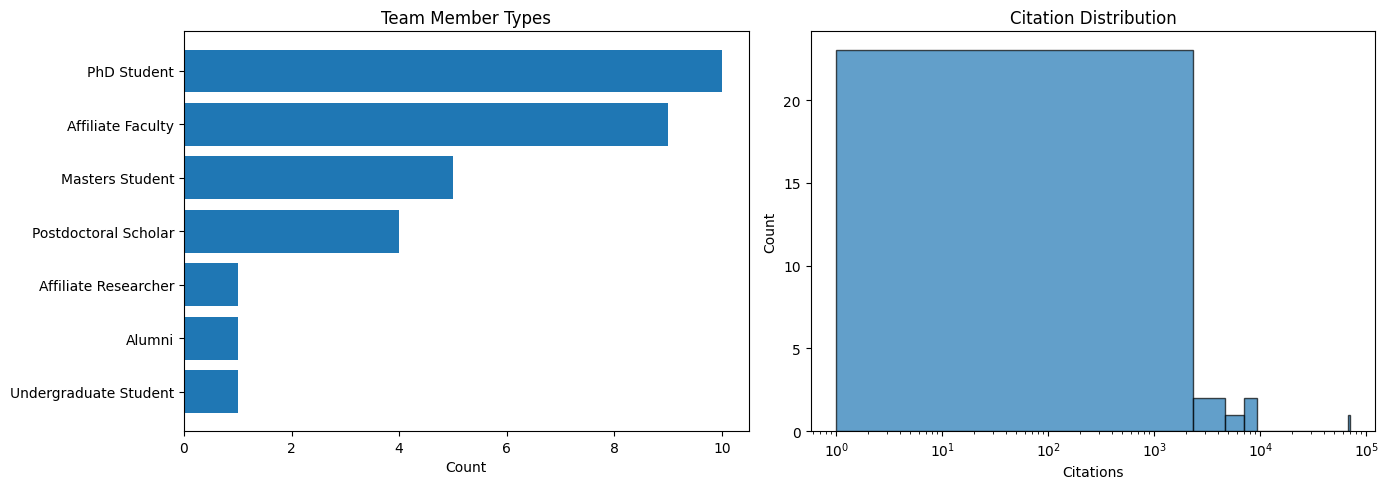

In [22]:
import matplotlib.pyplot as plt

# Distribution of team member types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Role distribution
role_counts = summary_df['Role'].value_counts()
axes[0].barh(role_counts.index, role_counts.values)
axes[0].set_xlabel('Count')
axes[0].set_title('Team Member Types')
axes[0].invert_yaxis()

# Citation distribution (log scale)
citations = summary_df[summary_df['Citations'] > 0]['Citations']
axes[1].hist(citations, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Citations')
axes[1].set_ylabel('Count')
axes[1].set_title('Citation Distribution')
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig('Data/klab_profile_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Topic analysis - what are the most common research topics?
from collections import Counter

all_topics = []
for p in profiles:
    if p.openalex_metrics and p.openalex_metrics.topics:
        for topic in p.openalex_metrics.topics:
            all_topics.append(topic['name'])

topic_counts = Counter(all_topics).most_common(20)

print("Top 20 Research Topics in Klab:")
print("="*50)
for topic, count in topic_counts:
    print(f"  {topic}: {count}")

Top 20 Research Topics in Klab:
  Opinion Dynamics and Social Influence: 3
  Complex Network Analysis Techniques: 2
  Housing, Finance, and Neoliberalism: 2
  Innovation and Knowledge Management: 2
  Misinformation and Its Impacts: 2
  Economic Growth and Development: 2
  Microfinance and Financial Inclusion: 2
  Social Media and Politics: 2
  Big Data and Business Intelligence: 2
  Innovative Microfluidic and Catalytic Techniques Innovation: 2
  Microfluidic and Bio-sensing Technologies: 2
  Advanced biosensing and bioanalysis techniques: 2
  Political Economy and Marxism: 1
  Social Capital and Networks: 1
  Formal Methods in Verification: 1
  Petri Nets in System Modeling: 1
  Influenza Virus Research Studies: 1
  Distributed systems and fault tolerance: 1
  Modular Robots and Swarm Intelligence: 1
  Ferroptosis and cancer prognosis: 1


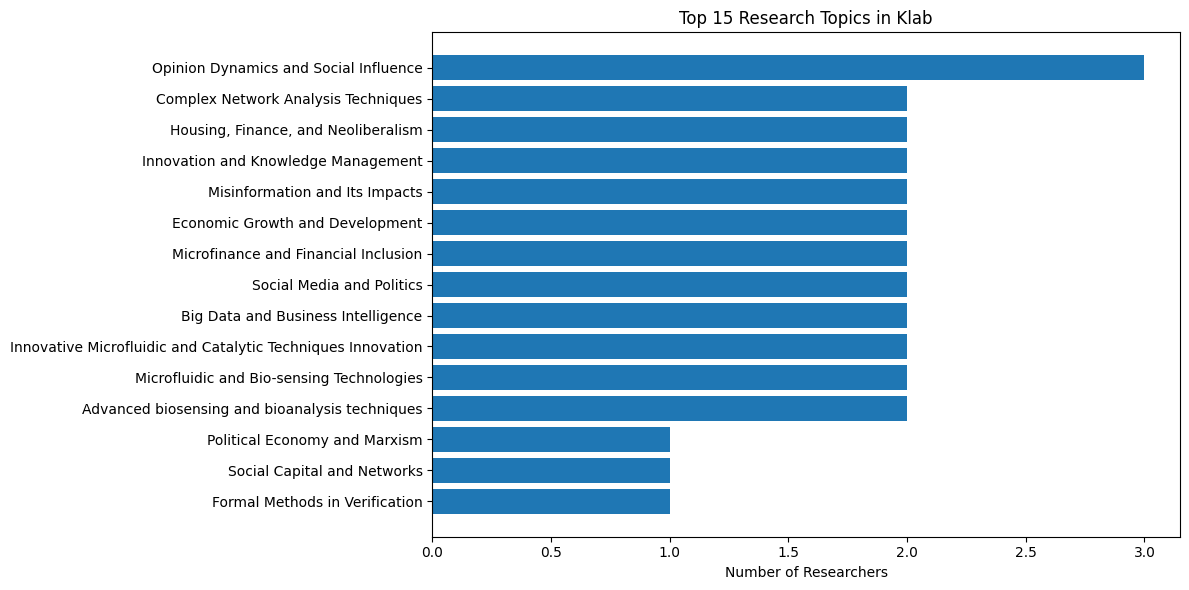

In [24]:
# Plot top topics
topics = [t[0] for t in topic_counts[:15]]
counts = [t[1] for t in topic_counts[:15]]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(topics[::-1], counts[::-1])
ax.set_xlabel('Number of Researchers')
ax.set_title('Top 15 Research Topics in Klab')
plt.tight_layout()
plt.savefig('Data/klab_topics.png', dpi=150, bbox_inches='tight')
plt.show()

## Individual Profile View

In [25]:
def display_profile(profile: ResearchProfile):
    """Display a formatted research profile"""
    print(f"\n{'='*70}")
    print(f"RESEARCH PROFILE: {profile.full_name}")
    print(f"{'='*70}")
    
    print(f"\n📧 Email: {profile.email}")
    print(f"🏛️  Institution: {profile.institution}")
    print(f"👤 Role: {profile.team_member_type}")
    
    if profile.personal_website:
        print(f"🌐 Website: {profile.personal_website}")
    
    if profile.bio:
        print(f"\n📝 Biography:")
        # Clean HTML tags if present
        bio_clean = re.sub('<[^<]+?>', '', profile.bio)
        print(f"   {bio_clean[:500]}{'...' if len(bio_clean) > 500 else ''}")
    
    if profile.openalex_metrics:
        oa = profile.openalex_metrics
        print(f"\n📊 OpenAlex Metrics:")
        print(f"   Publications: {oa.works_count}")
        print(f"   Total Citations: {oa.cited_by_count:,}")
        print(f"   h-index: {oa.h_index}")
        print(f"   i10-index: {oa.i10_index}")
        if oa.orcid:
            print(f"   ORCID: {oa.orcid}")
        
        if oa.topics:
            print(f"\n🔬 Research Topics:")
            for topic in oa.topics[:5]:
                print(f"   • {topic['name']} ({topic['count']} works)")
        
        if oa.recent_publications:
            print(f"\n📚 Top Publications:")
            for i, pub in enumerate(oa.recent_publications[:5], 1):
                print(f"   {i}. {pub.title[:70]}{'...' if len(pub.title) > 70 else ''}")
                print(f"      ({pub.year}) - {pub.citation_count} citations")
    
    print(f"\n{'='*70}")

In [26]:
# Display profiles for top researchers
for p, _ in profiles_with_citations[:3]:
    display_profile(p)


RESEARCH PROFILE: Rui Wang

📧 Email: rui_w@gwmail.gwu.edu
🏛️  Institution: GW School of Business
👤 Role: PhD Student
🌐 Website: www.wang-rui.com

📝 Biography:
   Rui (pronounced “ray”) Wang is a sixth-year Ph.D. student in the Strategic Management and Public Policy department at the GW School of Business. Her research broadly focuses on the role of emerging information and multimodal communication in advancing innovation and sustainability. She is currently working on projects related to climate risk disclosure and multimodal entrepreneurial storytelling on online platforms. Rui completed her graduate coursework at Nanjing University and earned a BA from...

📊 OpenAlex Metrics:
   Publications: 2091
   Total Citations: 69,907
   h-index: 117
   i10-index: 942
   ORCID: https://orcid.org/0000-0003-3825-3620

🔬 Research Topics:
   • Sulfur Compounds in Biology (206 works)
   • Ion channel regulation and function (72 works)
   • Nitric Oxide and Endothelin Effects (63 works)
   • Neurosc

## Interactive Profile Lookup

In [27]:
def find_profile(name: str, profiles: List[ResearchProfile]) -> Optional[ResearchProfile]:
    """Find a profile by name (partial match)"""
    name_lower = name.lower()
    for p in profiles:
        if name_lower in p.full_name.lower():
            return p
    return None

# Example: Look up a specific person
# profile = find_profile("Evans", profiles)
# if profile:
#     display_profile(profile)

In [28]:
# List all available profiles
print("Available profiles:")
for i, p in enumerate(profiles, 1):
    status = "✓" if p.openalex_metrics else "○"
    print(f"  {i:2d}. {status} {p.full_name} ({p.team_member_type})")

Available profiles:
   1. ✓ Jake Burchard (PhD Student)
   2. ✓ Ishanu Chattopadhyay (Affiliate Faculty)
   3. ✓ Ziwen Chen (PhD Student)
   4. ✓ Chris Esposito (Postdoctoral Scholar)
   5. ✓ Doug Guilbeault (Affiliate Faculty)
   6. ✓ Muhua Huang (Masters Student)
   7. ✓ Joshua Jackson (Affiliate Faculty)
   8. ✓ Shilin Jia (Postdoctoral Scholar)
   9. ✓ Partha Kadambi (Masters Student)
  10. ✓ Carina Kane (Undergraduate Student)
  11. ✓ Nadav Kunievsky (Postdoctoral Scholar)
  12. ✓ Ningzi Li (Postdoctoral Scholar)
  13. ✓ Qixin Lin (Masters Student)
  14. ✓ Chen Lin (PhD Student)
  15. ✓ Hsin-Keng Ling (Alumni)
  16. ✓ Bowen Lou (Affiliate Faculty)
  17. ✓ Hongkai Mao (PhD Student)
  18. ✓ Rui Pan (PhD Student)
  19. ○ Alejandro Sarria-Morales (Masters Student)
  20. ✓ Bill Shi (Affiliate Researcher)
  21. ✓ Wenxuan  Shi (PhD Student)
  22. ✓ Jamshid Sourati (Affiliate Faculty)
  23. ✓ Di Tong (PhD Student)
  24. ✓ Nicolás Torres-Echeverry (PhD Student)
  25. ✓ Lav Varshney (Affili

## Re-run for Specific Person (Optional)

If you want to build a profile with Google Scholar data for a specific person:

In [29]:
# Uncomment and modify to build a detailed profile for one person
# person_name = "James Evans"
# builder_with_scholar = ProfileBuilder(use_google_scholar=True)
# person_row = df[df['Last Name'].str.contains(person_name.split()[-1], case=False)].iloc[0]
# detailed_profile = builder_with_scholar.build_profile(person_row)
# display_profile(detailed_profile)